In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
start = '1989-01-01'
end = '2023-12-31'

stock = 'MSFT'
data = yf.download(stock,start,end)

/var/folders/_k/41pjm0pd4051klhdyyg2vvzw0000gn/T/ipykernel_56020/3583337468.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock,start,end)
[*********************100%***********************]  1 of 1 completed


In [3]:
data.reset_index(inplace=True)

In [4]:
data


Price,Date,Close,High,Low,Open,Volume
Ticker,,MSFT,MSFT,MSFT,MSFT,MSFT
0,1989-01-03,0.227480,0.228011,0.223768,0.226950,51825600
1,1989-01-04,0.230131,0.232782,0.226950,0.226950,53899200
2,1989-01-05,0.226420,0.232252,0.225890,0.232252,47246400
3,1989-01-06,0.224829,0.228011,0.224829,0.226950,59054400
4,1989-01-09,0.222708,0.225890,0.221117,0.224829,46008000
...,...,...,...,...,...,...
8812,2023-12-22,369.077087,369.668279,367.234564,368.190315,17107500
8813,2023-12-26,369.155945,371.402449,368.012983,369.490946,12673100
8814,2023-12-27,368.574646,369.550093,367.333147,368.200224,14905400


In [5]:
mva_days=data.Close.rolling(200).mean()
win_size=10
arr1=np.array(mva_days)

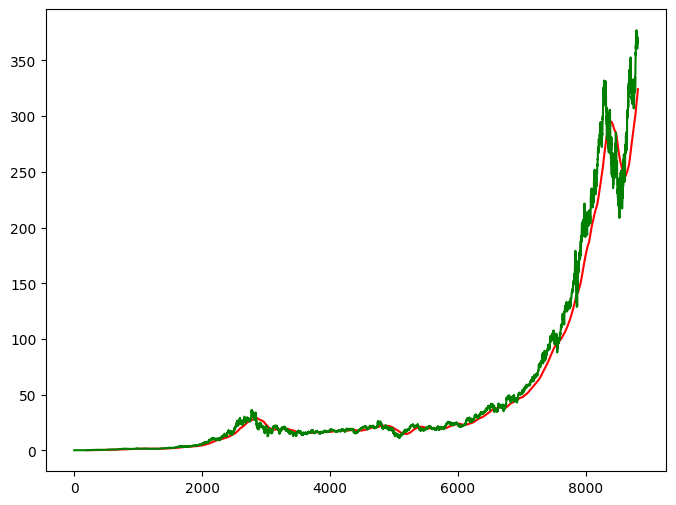

In [6]:
plt.figure(figsize=(8,6))
plt.plot(mva_days,'r')
plt.plot(data.Close,'g')
plt.show()

In [7]:
mva_days.dropna(inplace=True)

In [8]:
data_train = pd.DataFrame(mva_days[0: int(len(mva_days)*0.80)])
data_test = pd.DataFrame(mva_days[int(len(mva_days)*0.80): len(mva_days)])

In [9]:
data_train.shape[0]

6894

In [10]:
data_test.shape[0]

1724

In [11]:
from sklearn.preprocessing import MinMaxScaler as mms
scaler = mms(feature_range=(0,1))


In [12]:
data_train_scale=scaler.fit_transform(data_train)

In [13]:
x=[]
y=[]

for i in range (win_size,data_train_scale.shape[0]):
    x.append(data_train_scale[i-win_size:i])
    y.append(data_train_scale[i,0])

In [14]:
x, y = np.array(x), np.array(y)

In [15]:
import tensorflow.keras as keras
from keras.layers import Dense, Dropout,LSTM
from keras.models import Sequential

/Users/arpan25/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [16]:
model = Sequential()
model.add(LSTM(units = 50, return_sequences =True,
               input_shape = ((x.shape[1],1))))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, return_sequences =True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, return_sequences =True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, return_sequences =False))
model.add(Dropout(0.5))

model.add(Dense(units=1))

2025-12-22 08:04:36.843356: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-12-22 08:04:36.843495: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-22 08:04:36.843501: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-22 08:04:36.843676: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-22 08:04:36.843685: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/arpan25/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequenti

In [17]:
model.compile(optimizer = 'adam' , loss = 'mean_squared_error')

In [18]:
hist = model.fit(x,y, epochs = 400, batch_size = 256 , verbose = 1)

Epoch 1/400


2025-12-22 08:04:38.174039: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0729
Epoch 2/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0049
Epoch 3/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0029
Epoch 4/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0024
Epoch 5/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0023
Epoch 6/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0020
Epoch 7/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0021
Epoch 8/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0018
Epoch 9/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0018
Epoch 10/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0018
Epoch 11/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0017
Epoch 12/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0017
Epoch 13/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016
Epoch 14/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0014
Epoch 15/400
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0016
E

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 60)         │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 80)         │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,285 (2.05 MB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 357,524 (1.36 MB)

In [20]:
pst_days=data_train.tail(win_size)

In [21]:
data_test=pd.concat([pst_days,data_test],ignore_index=True)

In [22]:
data_test_scale =  scaler.fit_transform(data_test)

In [23]:
x=[]
y=[]

for i in range (win_size,data_test_scale.shape[0]):
    x.append(data_test_scale[i-win_size:i])
    y.append(data_test_scale[i,0])

x, y = np.array(x), np.array(y)

In [24]:
y_predict = model.predict(x)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [25]:
scale=1/scaler.scale_

In [26]:
y_predict=y_predict*scale

In [27]:
y=y*scale

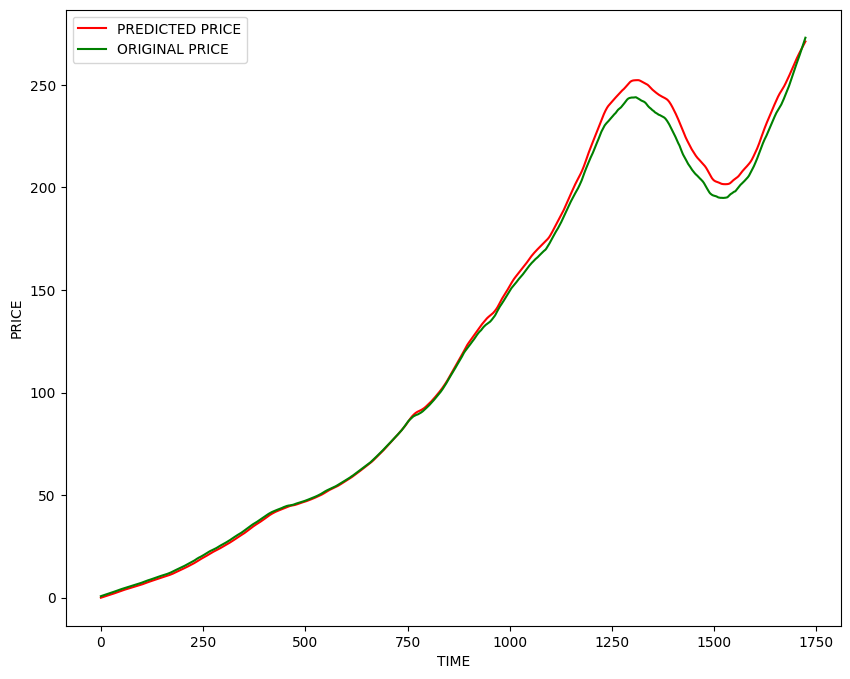

0.9972361851002463
20.067562147137366


In [28]:
plt.figure(figsize=(10,8))
plt.plot(y_predict,'r',label='PREDICTED PRICE')
plt.plot(y,'g',label='ORIGINAL PRICE')
plt.xlabel('TIME')
plt.ylabel('PRICE')
plt.legend()
plt.show()


from sklearn.metrics import r2_score as r2s
from sklearn.metrics import mean_squared_error as mse
r2 = r2s(y, y_predict)
mean_error = mse(y, y_predict)

print(r2)
print(mean_error)

In [30]:
model.save('Stock Predictions Model longterm 2025.keras')